# Backends: streamdf and Stream Gaps

This notebook describes how to use the action-angle stream model,
`streamdf`, and the stream-gap model, `streamgapdf`, with
[JAX](https://docs.jax.dev/) and [PyTorch](https://pytorch.org/). See the
[quick start](quickstart.ipynb) for an introduction to galpy's backends and
the [streamdf tutorial](../streams/streamdf.ipynb) for the models
themselves.

`streamdf` models a stream as a distribution in frequency and angle space,
computes the mean track of the stream in configuration space, and samples
and evaluates the DF around that track. On the backends:

* the track computation is a function of the progenitor's orbit and the
  potential that is differentiable from end to end, when the `streamdf` is
  set up with a progenitor `Orbit` from a backend array and an
  `actionAngleIsochroneApprox` instance that integrates in the backend;
* sampling with a backend random key draws by inverse transformation and
  returns backend arrays;
* the DF and its marginal distributions can be evaluated at backend arrays,
  differentiably.

In [1]:
%matplotlib inline
import time
import warnings

import jax

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
from galpy.util import galpyWarning

warnings.filterwarnings("ignore", category=galpyWarning)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy
import torch

from galpy.actionAngle import actionAngleIsochroneApprox
from galpy.backend import random as grandom
from galpy.df import streamdf
from galpy.df.streamgapdf import impulse_deltav_hernquist, impulse_deltav_plummer
from galpy.orbit import Orbit
from galpy.potential import LogarithmicHaloPotential
from galpy.util.conversion import time_in_Gyr

# A GD-1-like stream in a flattened logarithmic halo
prog = [1.56148083, 0.35081535, -1.15481504, 0.88719443, -0.47713334, 0.12019596]
sigv = 0.365  # km/s
tdisrupt = 4.5 / time_in_Gyr(220.0, 8.0)
lp = LogarithmicHaloPotential(normalize=1.0, q=0.9)

## Sampling and evaluating a `streamdf` on the backends

We set up the `streamdf` as usual, with NumPy and galpy's C integrators,
which is the fastest way to construct it on a CPU:

In [2]:
aAI = actionAngleIsochroneApprox(pot=lp, b=0.8)
start = time.perf_counter()
sdf = streamdf(
    sigv / 220.0,
    progenitor=Orbit(prog),
    pot=lp,
    aA=aAI,
    leading=True,
    nTrackChunks=11,
    tdisrupt=tdisrupt,
)
print(f"Construction: {time.perf_counter() - start:.1f} s")

Construction: 30.4 s


Given a JAX or PyTorch key, `sample` draws by inverse transformation and
returns backend arrays (here, the default `(R,vR,vT,z,vz,phi)` as an array
of shape `(6,n)`):

<class 'jaxlib._jax.ArrayImpl'> (6, 1000)


<class 'torch.Tensor'>


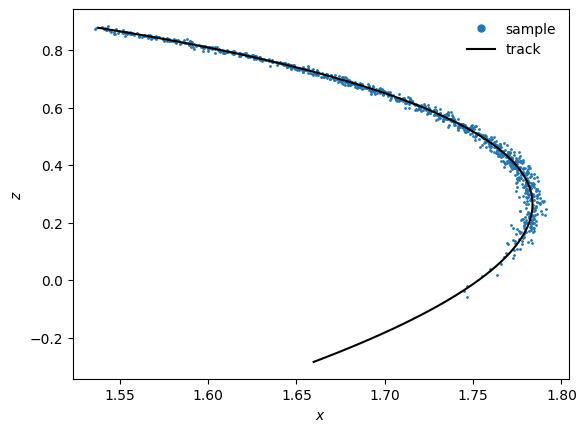

In [3]:
RvR = sdf.sample(n=1000, key=grandom.key(3, backend="jax"))
print(type(RvR), RvR.shape)
RvR_t = sdf.sample(n=1000, key=grandom.key(3, backend="torch"))
print(type(RvR_t))
track = sdf.streamTrack()
tp = track.tp_grid()
plt.plot(RvR[0] * jnp.cos(RvR[5]), RvR[3], ".", ms=2, label="sample")
plt.plot(track.x(tp), track.z(tp), "k-", label="track")
plt.xlabel(r"$x$")
plt.ylabel(r"$z$")
plt.legend(frameon=False, markerscale=5);

The DF and its marginal distributions can be evaluated at backend arrays
and differentiated. For example, the density along the stream as a function
of the parallel angle offset from the progenitor and its derivative,
vectorized with `jax.vmap`:

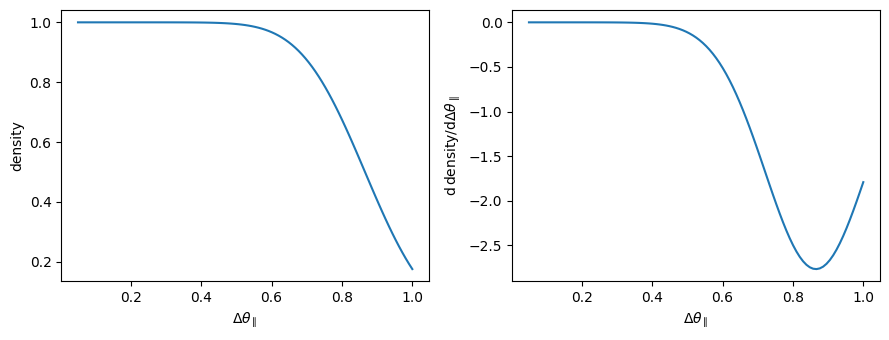

In [4]:
dangle = jnp.linspace(0.05, 1.0, 101)
dens = jax.vmap(sdf.density_par)(dangle)
ddens = jax.vmap(jax.grad(sdf.density_par))(dangle)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.plot(dangle, dens)
ax1.set_xlabel(r"$\Delta\theta_\parallel$")
ax1.set_ylabel("density")
ax2.plot(dangle, ddens)
ax2.set_xlabel(r"$\Delta\theta_\parallel$")
ax2.set_ylabel(r"$\mathrm{d}\,\mathrm{density}/\mathrm{d}\Delta\theta_\parallel$")
fig.tight_layout()

and the same with PyTorch:

In [5]:
da = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
sdf.density_par(da).backward()
print(da.grad, jax.grad(sdf.density_par)(0.5))

tensor(-0.1116, dtype=torch.float64) -0.11156192946565535


The full DF can be evaluated at backend phase-space positions as well:

In [6]:
print(sdf(*RvR[:, :5]))

[ 7.61429117 10.13226344  9.85419415  7.31078755  8.58686859]


## The derivative of the track with respect to the potential

When the `streamdf` is set up with a progenitor `Orbit` from a JAX array and
an `actionAngleIsochroneApprox` that integrates in the backend
(`integrate_method="diffrax"`), its construction, including the track, is a
JAX computation that is differentiable with respect to the parameters of the
potential and of the progenitor's orbit. Inside a differentiated or compiled
function, the number of track iterations must be given explicitly
(`nTrackIterations=`). Constructing the stream:

```python
pot = LogarithmicHaloPotential(normalize=1.0, q=q)
aAI = actionAngleIsochroneApprox(pot=pot, b=0.8, integrate_method="diffrax")
sdf = streamdf(
    sigv / 220.0,
    progenitor=Orbit(jnp.asarray(prog)),
    pot=pot,
    aA=aAI,
    leading=True,
    nTrackChunks=11,
    nTrackIterations=1,
    tdisrupt=tdisrupt,
)
```

inside a function of `q` gives a track whose derivative with respect to $q$
agrees with a finite difference of the same computation to the level set by
the fixed number of iterations of the track refinement (a few parts in
$10^4$). We do not run this here, because it is expensive on a CPU: the
construction integrates tens of orbits, which takes several minutes in eager
JAX, and differentiating the whole construction needs more than 16 GB of
memory eagerly and tens of minutes of compilation under `jax.jit`. It is
practical on a GPU or when many streams are to be built from one compiled
function. Currently, a differentiated track must also be read from the `streamdf`'s
internal track points (`sdf._ObsTrack`, as galpy's tests do) rather than
through `streamTrack()`, whose `StreamTrack` object cannot yet be built from
traced values.

The derivatives of stream models deserve a general comment. Because a stream
model is a generative model, the derivative of the track with respect to a
parameter can be taken either with the stream's stars held fixed or by
letting them move with the parameter. galpy's derivatives are of the second
kind, which is what a finite difference of the full model computes; the
first is not a physical quantity.

## Stream gaps: the kick kernels

The stream-gap model of Sanders, Bovy, & Erkal (2016), `streamgapdf`,
computes the velocity kick that a passing subhalo imparts along a stream in
the impulse approximation and propagates it through the action-angle model.
The kick kernels for Plummer and Hernquist subhalos run on the backends and
are differentiable with respect to the parameters of the impact. For a
straight stream moving along $y$ with unit speed and a Plummer subhalo with
mass `GM`, scale radius `rs`, velocity `w`, and impact parameter `b`, the kick
along the stream and its derivative with respect to the impact parameter:

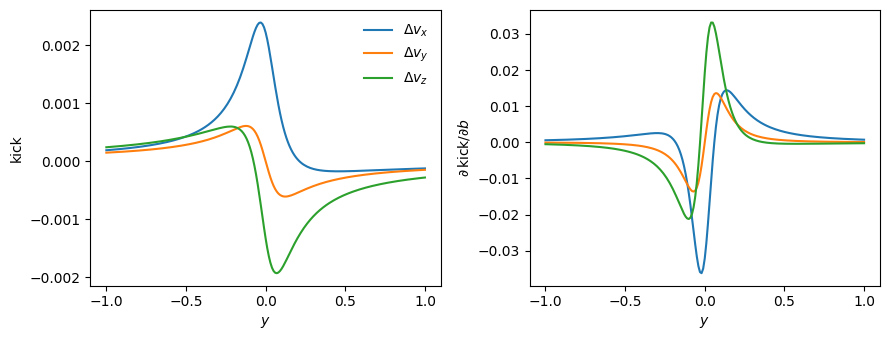

In [7]:
y = jnp.linspace(-1.0, 1.0, 201)  # position along the stream
v = jnp.tile(jnp.array([0.0, 1.0, 0.0]), (len(y), 1))  # stream velocity
w = jnp.array([0.3, -0.2, 0.5])  # subhalo velocity
GM, rs, b = 1e-4, 0.02, 0.05
dv = impulse_deltav_plummer(v, y, b, w, GM, rs)
ddv_db = jax.jacfwd(lambda b: impulse_deltav_plummer(v, y, b, w, GM, rs))(b)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
for ii, label in enumerate([r"$\Delta v_x$", r"$\Delta v_y$", r"$\Delta v_z$"]):
    ax1.plot(y, dv[:, ii], label=label)
    ax2.plot(y, ddv_db[:, ii])
ax1.set_xlabel(r"$y$")
ax1.set_ylabel("kick")
ax1.legend(frameon=False)
ax2.set_xlabel(r"$y$")
ax2.set_ylabel(r"$\partial\,\mathrm{kick} / \partial b$")
fig.tight_layout()

The derivative agrees with a finite difference of the NumPy kernel:

In [8]:
vn, yn, wn = numpy.asarray(v), numpy.asarray(y), numpy.asarray(w)
h = 1e-6
fd = (
    impulse_deltav_plummer(vn, yn, b + h, wn, GM, rs)
    - impulse_deltav_plummer(vn, yn, b - h, wn, GM, rs)
) / (2.0 * h)
print(numpy.max(numpy.fabs(ddv_db - fd)) / numpy.max(numpy.fabs(fd)))

2.8212892252377435e-10


and the Hernquist kernel works in the same way, here with PyTorch:

In [9]:
bt = torch.tensor(b, dtype=torch.float64, requires_grad=True)
dv_t = impulse_deltav_hernquist(
    torch.as_tensor(vn), torch.as_tensor(yn), bt, torch.as_tensor(wn), GM, rs
)
dv_t[:, 0].sum().backward()
print(bt.grad)

tensor(0.2494, dtype=torch.float64)


The kicks interpolated along the stream, the transformation to the impact
frame, and the orbit integrations in `streamgapdf` also run on the
backends. The construction of a `streamgapdf` itself is not traceable and
runs on NumPy.